**T_Hub_Data_Analysis**


In [ ]:
import pandas as pd , numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
access_logs = pd.read_csv('/content/access_logs.csv')
meeting_rooms = pd.read_csv('/content/meeting_rooms.csv')
payment = pd.read_csv('/content/payment.csv')
services = pd.read_csv('/content/services.csv')
staff = pd.read_csv('/content/staff.csv')
startups= pd.read_csv('/content/startups.csv')




In [ ]:
dataframes = [access_logs, meeting_rooms, payment, services, staff, startups]
for df in dataframes:
  #display(df.describe())
  print(df.isnull().sum())

Log_ID          0
Person_ID       0
Person_Type     0
ID_Card_Type    0
Card_Color      0
Entry_Time      0
Exit_Time       0
Device          0
WiFi_Login      0
dtype: int64
Room_ID                     0
Capacity                    0
Booked_Hours_Per_Day_Max    0
dtype: int64
Payment_ID      0
Payer_ID        0
Payment_Date    0
Payment_Type    0
Amount          0
dtype: int64
Record_ID               0
Startup_ID              0
Month                   0
Meeting_Room_Hours      0
Gym_Subscribed          0
Gaming_Paid             0
Cafe_Plan             989
WiFi_Devices            0
dtype: int64
Staff_ID      0
Name          0
Department    0
Role          0
Shift         0
dtype: int64
Startup_ID         0
Startup_Name       0
Industry           0
Join_Date          0
No_of_Employees    0
Office_Type        0
Mentor_Assigned    0
Funding_Stage      0
dtype: int64


In [ ]:
startups.columns.tolist()


['Startup_ID',
 'Startup_Name',
 'Industry',
 'Join_Date',
 'No_of_Employees',
 'Office_Type',
 'Mentor_Assigned',
 'Funding_Stage']

In [ ]:

services.columns.tolist()

['Record_ID',
 'Startup_ID',
 'Month',
 'Meeting_Room_Hours',
 'Gym_Subscribed',
 'Gaming_Paid',
 'Cafe_Plan',
 'WiFi_Devices']

In [ ]:
merge1 = pd.merge(startups,services , on = 'Startup_ID' , how='left')

In [ ]:
merge2 = pd.merge(payment, access_logs, left_on='Payer_ID', right_on='Person_ID', how='left')

In [ ]:
merged_final = pd.merge(merge1, merge2, left_on='Startup_ID', right_on='Payer_ID', how='left')
display(merged_final.head())

,Startup_ID,Startup_Name,Industry,Join_Date,No_of_Employees,Office_Type,Mentor_Assigned,Funding_Stage,Record_ID,Month,...,Amount,Log_ID,Person_ID,Person_Type,ID_Card_Type,Card_Color,Entry_Time,Exit_Time,Device,WiFi_Login
0,ST1000,Startup_0,Logistics,31-01-2023,100,Fixed,Yes,Series A,SVC3949,2023-05,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,ST1001,Startup_1,AI,30-12-2023,82,Flexi,No,Seed,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,ST1002,Startup_2,ClimateTech,10-05-2022,15,Fixed,Yes,Bootstrapped,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,ST1003,Startup_3,AI,18-07-2023,51,Fixed,No,Seed,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,ST1004,Startup_4,SaaS,04-02-2023,13,Fixed,No,Series A,SVC3316,2025-02,...,286494.42,LOG50022,ST1004,Startup Staff,Event,White,25-10-2024 13:01,25-10-2024 13:01,Mobile,0.0


In [ ]:
merged_final['Exit_Time'] = pd.to_datetime(merged_final['Exit_Time'], errors='coerce')
merged_final['Entry_Time'] = pd.to_datetime(merged_final['Entry_Time'], errors='coerce')

/tmp/ipykernel_1243/2304166034.py:1: UserWarning: Parsing dates in %d-%m-%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  merged_final['Exit_Time'] = pd.to_datetime(merged_final['Exit_Time'], errors='coerce')
/tmp/ipykernel_1243/2304166034.py:2: UserWarning: Parsing dates in %d-%m-%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  merged_final['Entry_Time'] = pd.to_datetime(merged_final['Entry_Time'], errors='coerce')


In [ ]:
merged_final['Entry_Hour'] = merged_final['Entry_Time'].dt.hour


Text(0.5, 1.0, 'Hourly Footfall Trend')

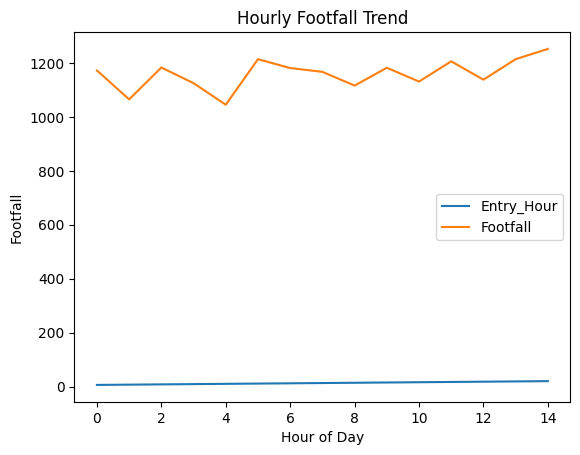

In [ ]:
hourly_footfall = merged_final.groupby('Entry_Hour').size().reset_index(name='Footfall')
hourly_footfall = hourly_footfall.sort_values('Entry_Hour')
hourly_footfall.plot(kind='line')
plt.xlabel("Hour of Day")
plt.ylabel("Footfall")
plt.title("Hourly Footfall Trend")

In [ ]:
merged_final.head()

,Startup_ID,Startup_Name,Industry,Join_Date,No_of_Employees,Office_Type,Mentor_Assigned,Funding_Stage,Record_ID,Month,...,Log_ID,Person_ID,Person_Type,ID_Card_Type,Card_Color,Entry_Time,Exit_Time,Device,WiFi_Login,Entry_Hour
0,ST1000,Startup_0,Logistics,31-01-2023,100,Fixed,Yes,Series A,SVC3949,2023-05,...,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN
1,ST1001,Startup_1,AI,30-12-2023,82,Flexi,No,Seed,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN
2,ST1002,Startup_2,ClimateTech,10-05-2022,15,Fixed,Yes,Bootstrapped,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN
3,ST1003,Startup_3,AI,18-07-2023,51,Fixed,No,Seed,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN
4,ST1004,Startup_4,SaaS,04-02-2023,13,Fixed,No,Series A,SVC3316,2025-02,...,LOG50022,ST1004,Startup Staff,Event,White,2024-10-25 13:01:00,2024-10-25 13:01:00,Mobile,0.0,13.0


In [ ]:
startup_revenue = merged_final.groupby('Startup_Name')['Amount'].sum().reset_index()
print(startup_revenue.head())

   Startup_Name      Amount
0     Startup_0        0.00
1     Startup_1        0.00
2    Startup_10  7097079.42
3   Startup_100   584326.53
4  Startup_1000        0.00


**Reasoning**:
Now that the total revenue per startup has been calculated, I will sort the `startup_revenue` DataFrame in descending order by the 'Amount' column and select the top 10 entries. This will identify the top 10 startups by total revenue.



In [ ]:
top_10_startups = startup_revenue.sort_values(by='Amount', ascending=False).head(10)
print(top_10_startups)

      Startup_Name       Amount
1348   Startup_411  68726938.15
803   Startup_1720  38035694.73
1178   Startup_259  31715209.26
680    Startup_161  29544751.80
1825   Startup_841  27043060.14
749   Startup_1672  25500198.90
782   Startup_1701  25103995.80
1045  Startup_1939  24320765.04
617   Startup_1553  24209784.32
70    Startup_1060  22621008.33


**Reasoning**:
To visualize the total revenue of the top 10 startups, I will create a bar chart using the `top_10_startups` DataFrame. The x-axis will represent 'Startup_Name' and the y-axis will represent 'Amount'.



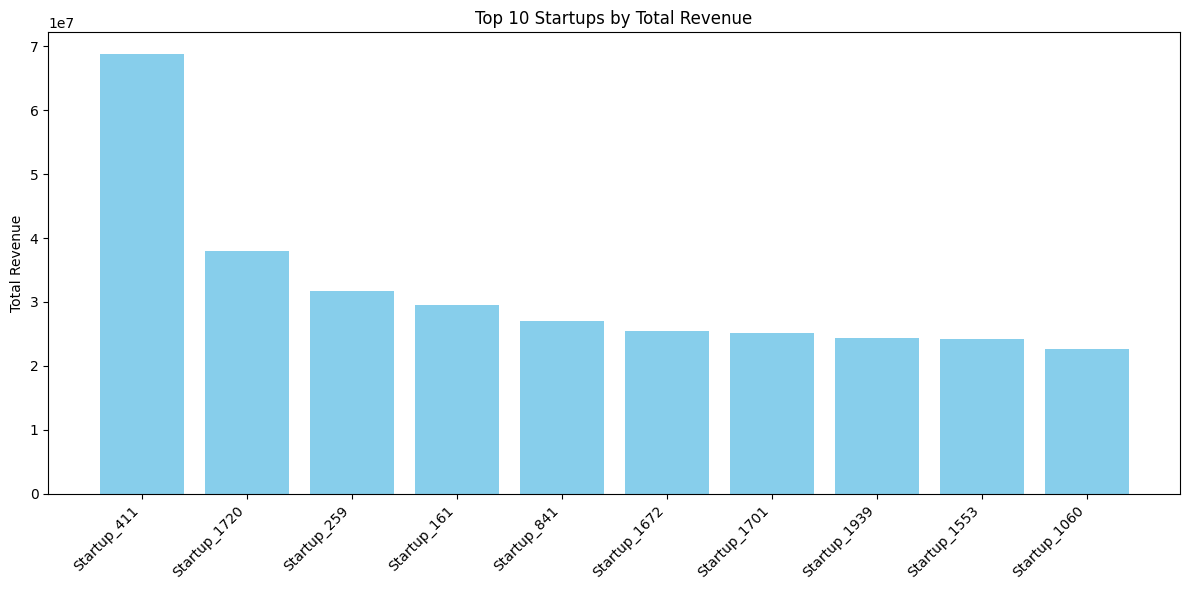

In [ ]:
plt.figure(figsize=(12, 6))
plt.bar(top_10_startups['Startup_Name'], top_10_startups['Amount'], color='skyblue')
plt.xticks(rotation=45, ha='right')
plt.xlabel('')
plt.ylabel('Total Revenue')
plt.title('Top 10 Startups by Total Revenue')
plt.tight_layout()
plt.show()

In [ ]:
late_night_staff_access = merged_final[
    (merged_final['Person_Type'] == 'Startup Staff') &
    (merged_final['Exit_Time'].dt.hour >= 20)
].copy()

late_night_staff_access['Late_Night_Date'] = late_night_staff_access['Exit_Time'].dt.date

consistently_late_workers = (
    late_night_staff_access.groupby('Person_ID')['Late_Night_Date']
    .nunique()
    .reset_index(name='Distinct_Late_Night_Days')
)

consistently_late_workers = consistently_late_workers.sort_values(
    by='Distinct_Late_Night_Days', ascending=False
)

display(consistently_late_workers.head())

,Person_ID,Distinct_Late_Night_Days
298,ST2258,5
19,ST1063,4
402,ST2687,4
120,ST1458,4
406,ST2697,3


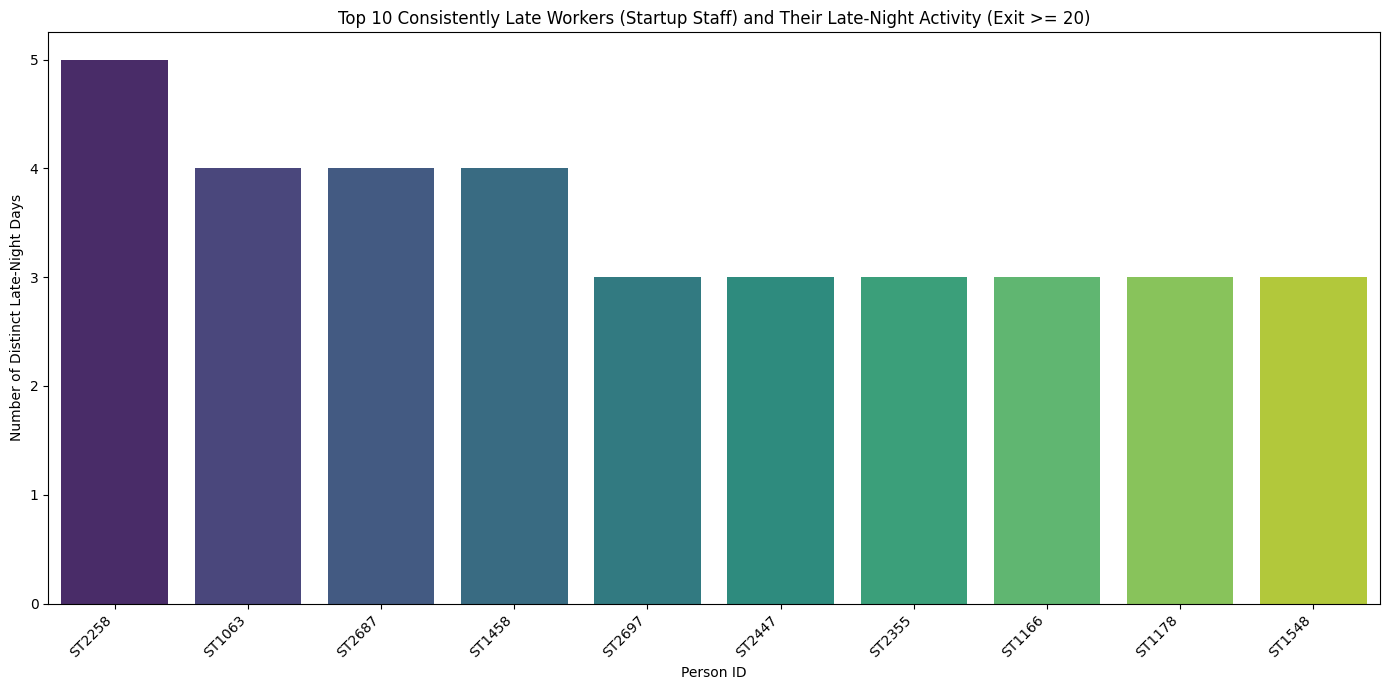

In [ ]:
plt.figure(figsize=(14, 7))
sns.barplot(x='Person_ID', y='Distinct_Late_Night_Days', data=consistently_late_workers.head(10), palette='viridis', hue='Person_ID', legend=False)
plt.xticks(rotation=45, ha='right')
plt.xlabel('Person ID')
plt.ylabel('Number of Distinct Late-Night Days')
plt.title('Top 10 Consistently Late Workers (Startup Staff) and Their Late-Night Activity (Exit >= 20)')
plt.tight_layout()
plt.show()

In [ ]:
services['Month'] = pd.to_datetime(services['Month'], errors='coerce')
monthly_meeting_hours = services.groupby('Month')['Meeting_Room_Hours'].sum().reset_index()
monthly_meeting_hours.head()

,Month,Meeting_Room_Hours
0,2023-01-01,192
1,2023-02-01,193
2,2023-03-01,239
3,2023-04-01,145
4,2023-05-01,209


In [ ]:
monthly_meeting_hours['time_idx'] = range(len(monthly_meeting_hours))
monthly_meeting_hours.head()

,Month,Meeting_Room_Hours,time_idx
0,2023-01-01,192,0
1,2023-02-01,193,1
2,2023-03-01,239,2
3,2023-04-01,145,3
4,2023-05-01,209,4


In [ ]:
from sklearn.linear_model import LinearRegression

X = monthly_meeting_hours[['time_idx']]
y = monthly_meeting_hours['Meeting_Room_Hours']

model = LinearRegression()
model.fit(X, y)
print("Linear regression model trained successfully.")

Linear regression model trained successfully.


In [ ]:
last_time_idx = monthly_meeting_hours['time_idx'].max()
future_time_idx = pd.DataFrame({'time_idx': range(last_time_idx + 1, last_time_idx + 7)})
future_predictions = model.predict(future_time_idx[['time_idx']])
future_time_idx['Predicted_Meeting_Room_Hours'] = future_predictions
print("Future predictions generated successfully.")
future_time_idx.head()

Future predictions generated successfully.


,time_idx,Predicted_Meeting_Room_Hours
0,35,152.178151
1,36,151.118207
2,37,150.058263
3,38,148.998319
4,39,147.938375


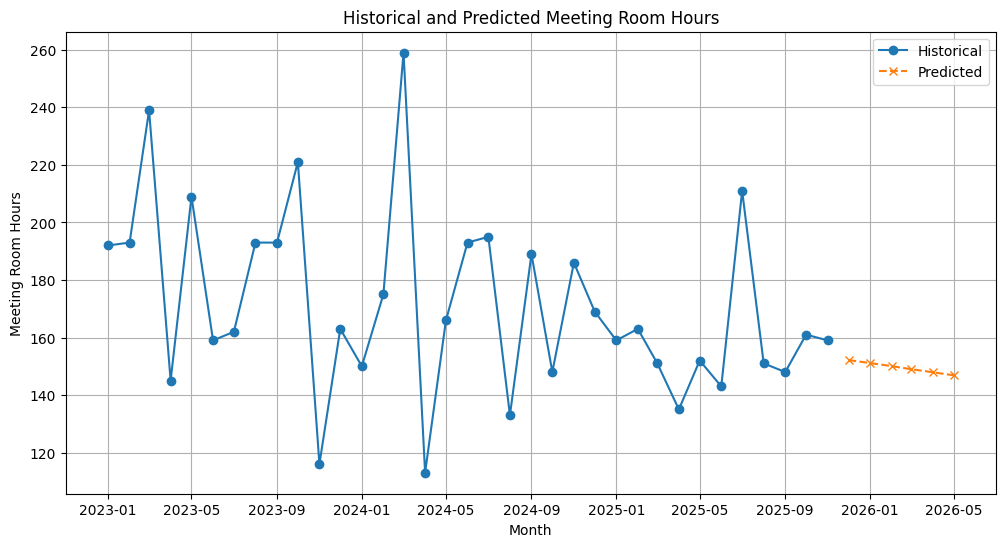

Plot of historical and predicted meeting room hours generated.


In [ ]:
import matplotlib.pyplot as plt

# Generate future month dates for plotting
last_month = monthly_meeting_hours['Month'].max()
future_months = [last_month + pd.DateOffset(months=i) for i in range(1, 7)]
future_time_idx['Month'] = future_months

# Rename the predicted column for consistency with historical data
future_time_idx = future_time_idx.rename(columns={'Predicted_Meeting_Room_Hours': 'Meeting_Room_Hours'})

# Combine historical and predicted data for plotting
combined_data = pd.concat([monthly_meeting_hours[['Month', 'Meeting_Room_Hours']], future_time_idx[['Month', 'Meeting_Room_Hours']]], ignore_index=True)

# Plotting
plt.figure(figsize=(12, 6))
plt.plot(monthly_meeting_hours['Month'], monthly_meeting_hours['Meeting_Room_Hours'], label='Historical', marker='o')
plt.plot(future_time_idx['Month'], future_time_idx['Meeting_Room_Hours'], label='Predicted', linestyle='--', marker='x')
plt.xlabel('Month')
plt.ylabel('Meeting Room Hours')
plt.title('Historical and Predicted Meeting Room Hours')
plt.legend()
plt.grid(True)
plt.show()
print("Plot of historical and predicted meeting room hours generated.")

In [ ]:
merged_final['Access_Hours'] = (
    (merged_final['Exit_Time'] - merged_final['Entry_Time']).dt.total_seconds()
) / 3600


In [ ]:
Q1 = merged_final['Access_Hours'].quantile(0.25)
Q3 = merged_final['Access_Hours'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
condition = (
    (merged_final['Access_Hours'] < lower_bound) |
    (merged_final['Access_Hours'] > upper_bound))
outliers =merged_final.loc[condition]
print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)
print("Total outliers:", len(outliers))
print("Percentage:", len(outliers) / len(merged_final) * 100)

Lower bound: 0.0
Upper bound: 0.0
Total outliers: 0
Percentage: 0.0


In [ ]:
merged_final['Payment_Date'] = pd.to_datetime(merged_final['Payment_Date'])
merged_final['Month'] = merged_final['Payment_Date'].dt.to_period('M')
monthly_payments = (
merged_final.groupby(['Startup_ID', 'Month'])['Payment_ID']
    .count()
    .reset_index())
monthly_payments['Renew_Next_Month'] = (
monthly_payments.groupby('Startup_ID')['Payment_ID']
    .shift(-1))
monthly_payments['Renew_Next_Month'] = (
monthly_payments['Renew_Next_Month']
    .apply(lambda x: 1 if x > 0 else 0))

/tmp/ipykernel_1243/285429408.py:1: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  merged_final['Payment_Date'] = pd.to_datetime(merged_final['Payment_Date'])


In [ ]:
monthly_features = (
merged_final.groupby(['Startup_ID', 'Month']).agg({
'Meeting_Room_Hours':'sum',
'WiFi_Devices':'mean',
'Amount':'sum',
'No_of_Employees':'first'
    }).reset_index())
model_df = pd.merge(
monthly_features,
monthly_payments[['Startup_ID','Month','Renew_Next_Month']],
on=['Startup_ID','Month'],
how='inner')
model_df = model_df.dropna()


In [ ]:
from sklearn.model_selection import train_test_split
X = model_df.drop(['Startup_ID','Month','Renew_Next_Month'], axis=1)
y = model_df['Renew_Next_Month']
X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.2, random_state=42
)


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced'
)

model.fit(X_train, y_train)

predictions = model.predict(X_test)

print(confusion_matrix(y_test, predictions))
print(classification_report(y_test, predictions))

[[56 47]
 [24 23]]
              precision    recall  f1-score   support

           0       0.70      0.54      0.61       103
           1       0.33      0.49      0.39        47

    accuracy                           0.53       150
   macro avg       0.51      0.52      0.50       150
weighted avg       0.58      0.53      0.54       150



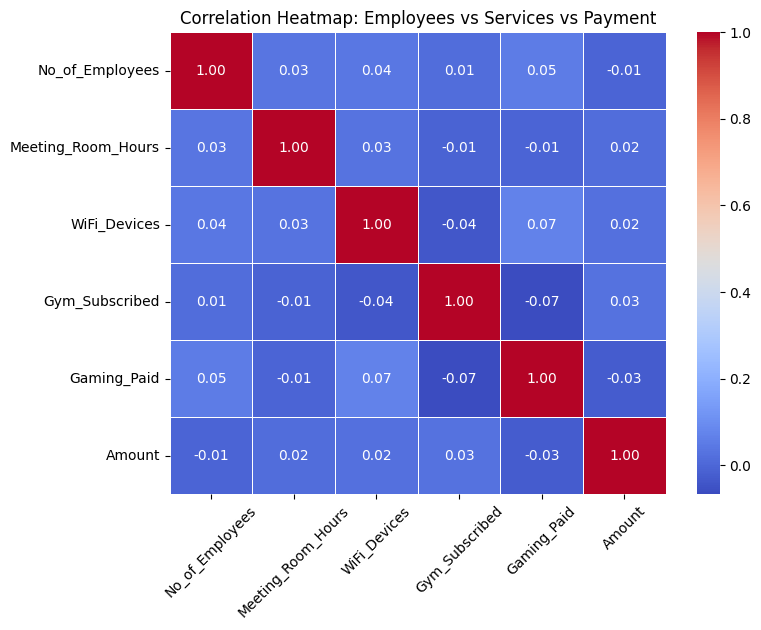

In [ ]:
import seaborn as sns
corr_df = merged_final[[
'No_of_Employees',
'Meeting_Room_Hours',
'WiFi_Devices',
'Gym_Subscribed',
'Gaming_Paid',
'Amount'
]]
corr_matrix = corr_df.corr()
plt.figure(figsize=(8,6))
sns.heatmap(
corr_matrix,
annot=True,
fmt=".2f",
cmap="coolwarm",
linewidths=0.5
)
plt.title("Correlation Heatmap: Employees vs Services vs Payment")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.show()


In [ ]:
def get_startup_summary(startup_name):
    startup_df = merged_final[merged_final['Startup_Name'].str.lower() == startup_name.lower()]
    if startup_df.empty:
        return {"error": "Startup not found"}
    summary = {
        "Startup_Name": startup_name,
        "Industry": startup_df['Industry'].iloc[0],
        "Funding_Stage": startup_df['Funding_Stage'].iloc[0],
        "No_of_Employees": int(startup_df['No_of_Employees'].iloc[0]),
        "Total_Revenue": float(startup_df['Amount'].sum()),
        "Total_Meeting_Room_Hours": float(startup_df['Meeting_Room_Hours'].sum()),
        "Avg_WiFi_Devices": float(startup_df['WiFi_Devices'].mean()),
        "Gym_Subscriptions": int(startup_df['Gym_Subscribed'].sum()),
        "Gaming_Usage_Count": int(startup_df['Gaming_Paid'].sum())
    }
    return summary

In [ ]:
get_startup_summary("Startup_2000")

{'error': 'Startup not found'}

In [ ]:
get_startup_summary("Startup_1999")

{'Startup_Name': 'Startup_1999',
 'Industry': 'SaaS',
 'Funding_Stage': 'Seed',
 'No_of_Employees': 105,
 'Total_Revenue': 3290032.9999999995,
 'Total_Meeting_Room_Hours': 0.0,
 'Avg_WiFi_Devices': 23.0,
 'Gym_Subscriptions': 0,
 'Gaming_Usage_Count': 0}